# Práctica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income (Ingresos en Censos de Adultos)

**Objetivo de la Práctica:**
Aplicar de manera estructurada y autónoma el flujo completo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real. El flujo de trabajo emula el nivel técnico y la rigurosidad aplicados en el Laboratorio 11 (Titanic), permitiendo la fácil comprensión del pipeline para su posterior exposición académica.

**Contexto del Problema:**
Una institución financiera desea analizar las características demográficas, educativas y laborales de distintos individuos para determinar qué factores están más fuertemente asociados con ingresos anuales superiores a $50,000 dólares. El objetivo principal consiste en construir un modelo clasificador (Árbol de Decisión) capaz de predecir si una persona pertenece al grupo de ingresos:
- `<=50K` (Menor o igual a 50,000 dólares anuales)
- `>50K` (Mayor a 50,000 dólares anuales)

## Parte 1. Importación de Librerías
En esta sección importamos las librerías necesarias para el análisis exploratorio de datos, visualización gráfica, preprocesamiento y modelado predictivo.

In [15]:
# Importamos librerías estándar de manipulación y análisis de datos
import pandas as pd
import numpy as np

# Importamos herramientas de modelado de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Importamos herramientas de graficación
import seaborn as sns
import matplotlib.pyplot as plt

# Importamos kagglehub para descargar de manera segura el dataset
!pip install kagglehub
import kagglehub

## Parte 2. Carga del Dataset
Descargamos de manera automatizada la última versión del dataset `Adult Census Income` a través de `kagglehub` y procedemos a cargarlo en un DataFrame de Pandas.

In [2]:
# Descarga automática del dataset de Kaggle
path = kagglehub.dataset_download("uciml/adult-census-income")
print("Ruta del dataset descargado:", path)

# Carga del archivo CSV en un DataFrame
dfAdult = pd.read_csv(path + "/adult.csv")

# Visualización de las primeras 5 filas del dataset
dfAdult.head()

Ruta del dataset descargado: C:\Users\villa\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Parte 3. Comprensión del Problema y Exploración Inicial (EDA)
Analizamos la distribución de la variable objetivo (`income`) y visualizamos de forma descriptiva el comportamiento general de la población bajo estudio.

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Porcentaje de distribución:
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


C:\Users\villa\AppData\Local\Temp\ipykernel_23004\4246854744.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="income", data=dfAdult, palette="coolwarm")


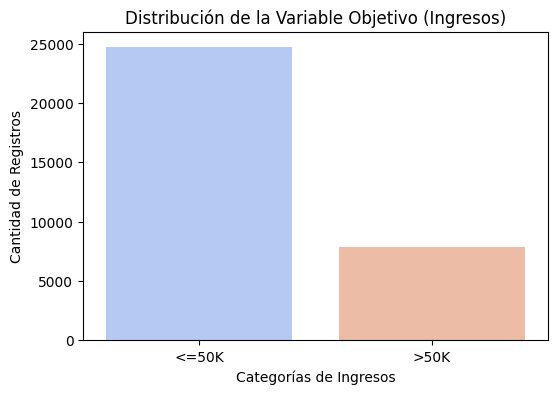

In [3]:
# Contamos los registros para cada clase de ingresos (variable objetivo)
print(dfAdult["income"].value_counts())
print("\nPorcentaje de distribución:")
print(dfAdult["income"].value_counts(normalize=True) * 100)

# Graficamos la distribución de la variable objetivo para exposición escolar
plt.figure(figsize=(6, 4))
sns.countplot(x="income", data=dfAdult, palette="coolwarm")
plt.title("Distribución de la Variable Objetivo (Ingresos)")
plt.xlabel("Categorías de Ingresos")
plt.ylabel("Cantidad de Registros")
plt.show()

### Exploración de variables adicionales e Hipótesis Iniciales
Realizamos análisis estadísticos básicos sobre los datos para formular hipótesis sobre qué factores influyen en el ingreso.

In [4]:
# Descripción estadística para variables numéricas
print("Resumen descriptivo del dataset:")
print(dfAdult.describe())

# Análisis de relación entre nivel educativo y probabilidad de ingreso >50K
# Primero creamos una versión temporal numérica de la variable objetivo
dfAdult['income_num'] = dfAdult['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Relación de ingresos con la variable escolaridad (education.num)
print("\nTasa de ingresos >50K promedio por nivel educativo (años):")
print(dfAdult.groupby('education.num')['income_num'].mean().sort_index())

# Relación de ingresos con el estado civil
print("\nTasa de ingresos >50K promedio por estado civil:")
print(dfAdult.groupby('marital.status')['income_num'].mean().sort_values(ascending=False))

Resumen descriptivo del dataset:
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

Tasa de ingresos >50K promedi

## Parte 4. Correlación e Hipótesis
Creamos una matriz de correlación para identificar la relación lineal entre las variables numéricas y la variable objetivo.

                income_num       age    fnlwgt  education.num  capital.gain  \
income_num        1.000000  0.234037 -0.009463       0.335154      0.223329   
age               0.234037  1.000000 -0.076646       0.036527      0.077674   
fnlwgt           -0.009463 -0.076646  1.000000      -0.043195      0.000432   
education.num     0.335154  0.036527 -0.043195       1.000000      0.122630   
capital.gain      0.223329  0.077674  0.000432       0.122630      1.000000   
capital.loss      0.150526  0.057775 -0.010252       0.079923     -0.031615   
hours.per.week    0.229689  0.068756 -0.018768       0.148123      0.078409   

                capital.loss  hours.per.week  
income_num          0.150526        0.229689  
age                 0.057775        0.068756  
fnlwgt             -0.010252       -0.018768  
education.num       0.079923        0.148123  
capital.gain       -0.031615        0.078409  
capital.loss        1.000000        0.054256  
hours.per.week      0.054256        1.

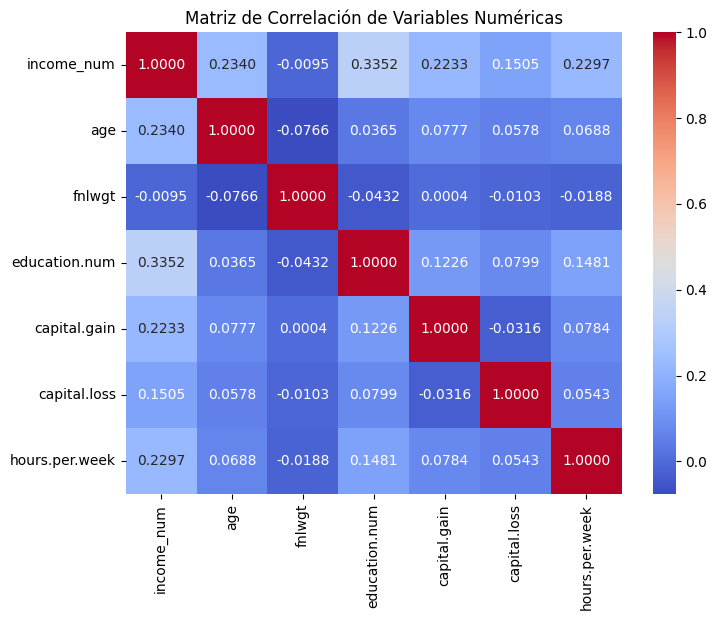

In [5]:
# Definimos la lista de variables numéricas, incluyendo nuestra variable objetivo numérica temporal
variables_numericas = [
    "income_num",
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

# Calculamos la matriz de correlación
corr = dfAdult[variables_numericas].corr()
print(corr)

# Generamos el gráfico de calor (Heatmap) para la exposición
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

# Eliminamos la columna temporal para no afectar el preprocesamiento limpio posterior
dfAdult = dfAdult.drop(columns=['income_num'])

## Parte 5. Selección de Variables Predictoras y Objetivo
Definimos la matriz de características predictoras (`X`) y el vector con la variable objetivo (`Y`). Transformamos también la variable objetivo de texto a valores binarios (0 para `<=50K` y 1 para `>50K`), tal como se preprocesó la columna `Survived` en el Lab 11.

In [6]:
# Convertimos la variable objetivo a binario
Y = dfAdult["income"].apply(lambda x: 0 if x == "<=50K" else 1)
Y.name = "income"

# Definimos las variables predictoras (eliminamos 'income')
X = dfAdult.drop(columns=["income"])

print("Variables predictoras incluidas:", X.columns.tolist())
print("Variable objetivo:", Y.name)

Variables predictoras incluidas: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']
Variable objetivo: income


## Parte 6. Tratamiento de los Valores Nulos
El dataset de Adult Income contiene valores faltantes codificados con el carácter `'?'`. En esta sección, identificamos estos nulos ocultos, los reemplazamos por `NaN` de NumPy y procedemos a su imputación.

In [7]:
# Primero revisamos si hay valores nulos detectados de forma tradicional por pandas
print("Nulos iniciales por columna:\n", X.isnull().sum())

# Identificamos la presencia de '?' en las columnas del conjunto predictivo
for col in X.columns:
    if X[col].dtype == object:
        cant_preguntas = (X[col] == '?').sum()
        if cant_preguntas > 0:
            print(f"La columna '{col}' contiene {cant_preguntas} valores '?'")

# Reemplazamos todos los caracteres '?' por valores nulos reales NaN
X = X.replace('?', np.nan)

print("\nNulos detectados tras reemplazar '?':\n", X.isnull().sum())

# Imputamos los valores nulos categóricos utilizando la moda (valor más frecuente)
# (workclass, occupation y native.country son categóricas)
for col in ["workclass", "occupation", "native.country"]:
    X[col] = X[col].fillna(X[col].mode()[0])

# Verificamos que no queden valores nulos en el conjunto predictivo
print("\nNulos por columna después de la imputación:\n", X.isnull().sum())

Nulos iniciales por columna:
 age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64

Nulos detectados tras reemplazar '?':
 age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
dtype: int64

Nulos por columna después de la imputación:
 age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week  

## Parte 7. One-Hot Encoding (Transformación de Variables Categóricas)
Dado que los modelos de clasificación requieren entradas numéricas, transformamos las variables cualitativas utilizando codificación One-Hot Encoding. Para evitar redundancia en las columnas y el fenómeno de la multicolinealidad, usaremos la opción `drop_first=True` tal como en la práctica del Titanic.

In [8]:
# Listamos las variables categóricas que necesitan transformación
variables_categoricas = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]

print("Dimensiones antes del One-Hot Encoding:", X.shape)

# Aplicamos One-Hot Encoding mediante pd.get_dummies
X = pd.get_dummies(X, columns=variables_categoricas, drop_first=True)

print("Dimensiones después del One-Hot Encoding:", X.shape)
X.head()

Dimensiones antes del One-Hot Encoding: (32561, 14)
Dimensiones después del One-Hot Encoding: (32561, 97)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


## Parte 8. Particionado de los Datos (Train/Test Split)
Dividimos el conjunto de datos en una sección de entrenamiento (80%) y una de pruebas (20%), utilizando el mismo estado aleatorio fijo (`random_state=42`) para garantizar la reproducibilidad académica.

In [9]:
# Realizamos la partición de entrenamiento y pruebas
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Imprimimos las dimensiones resultantes para la exposición
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("Etiquetas Entrenamiento:", Y_train.shape)
print("Etiquetas Prueba:", Y_test.shape)

Entrenamiento: (26048, 97)
Prueba: (6513, 97)
Etiquetas Entrenamiento: (26048,)
Etiquetas Prueba: (6513,)


## Parte 9. Escalado de las Variables Numéricas
Las variables numéricas tienen rangos de valores muy dispares (por ejemplo, el peso final `fnlwgt` vs. la edad `age`). Aplicamos `StandardScaler` sobre estas columnas para evitar que las variables con magnitudes mayores sesguen el modelo de clasificación. 

**Regla Importante:** La media y la desviación estándar deben ser obtenidas únicamente del conjunto de entrenamiento (`fit_transform`) y aplicadas al conjunto de pruebas (`transform`), previniendo fugas de información (data leakage).

In [10]:
# Definimos el listado de columnas numéricas del dataset
columnas_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

# Inicializamos el escalador estándar
scaler = StandardScaler()

# Ajustamos y transformamos el conjunto de entrenamiento
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])

# Transformamos el conjunto de prueba usando los parámetros del entrenamiento
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# Verificamos las estadísticas del conjunto de entrenamiento escalado
X_train[columnas_numericas].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,-1.753989e-16,-1.009294e-16,1.421195e-16,-2.291369e-17,-4.146287e-17,8.729026e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.584336e+00,-1.690420e+00,-3.521699e+00,-1.471664e-01,-2.176795e-01,-3.204476e+00
25%,-7.747588e-01,-6.842442e-01,-4.217268e-01,-1.471664e-01,-2.176795e-01,-4.208134e-02
50%,-1.123775e-01,-1.078053e-01,-3.423025e-02,-1.471664e-01,-2.176795e-01,-4.208134e-02
75%,6.236017e-01,4.534354e-01,1.128259e+00,-1.471664e-01,-2.176795e-01,3.633539e-01
max,3.788312e+00,1.205002e+01,2.290749e+00,1.315328e+01,1.049046e+01,4.742055e+00


## Parte 10. Entrenamiento del Modelo de Árbol de Decisión
Construimos el modelo clasificador utilizando un árbol de decisión de profundidad máxima de 4 y con estado de aleatoriedad fijo para comparar de forma justa el desempeño en la presentación.

In [11]:
# Instanciamos el clasificador de Árbol de Decisión
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Entrenamos el modelo con los datos escalados de entrenamiento
modelo.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Parte 11. Predicciones
Utilizamos el modelo entrenado para generar predicciones en el conjunto de prueba y creamos un DataFrame para contrastar los valores reales con los valores predichos.

In [12]:
# Generamos las predicciones del conjunto de prueba
predicciones = modelo.predict(X_test)

# Generamos la tabla comparativa de valores reales y predicciones
tabla_comparacion = pd.DataFrame({
    "Real": Y_test,
    "Predicción": predicciones
})

# Mostramos las primeras 10 predicciones
tabla_comparacion.head(10)

,Real,Predicción
14160,0,0
27048,0,0
28868,0,0
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


## Parte 12. Accuracy (Exactitud del Modelo)
Calculamos la proporción de predicciones correctas que obtuvo el modelo sobre el conjunto de test.

In [13]:
# Calculamos el Accuracy score
exactitud = accuracy_score(Y_test, predicciones)

# Imprimimos el resultado formateado a cuatro decimales
print(f"Accuracy del modelo: {exactitud:.4f}")

Accuracy del modelo: 0.8449


## Parte 13. Importancia de las Variables (Feature Importance)
Obtenemos la contribución de cada variable predictora en la reducción del criterio de impureza de Gini durante la partición del árbol.

In [14]:
# Creamos un DataFrame con las variables y sus respectivas importancias
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_
})

# Ordenamos de forma descendente por nivel de importancia
importancias = importancias.sort_values(by="Importancia", ascending=False)

# Mostramos las variables más influyentes
importancias.head(10)

,Variable,Importancia
29,marital.status_Married-civ-spouse,0.491686
2,education.num,0.248290
3,capital.gain,0.225830
4,capital.loss,0.021809
0,age,0.011251
1,fnlwgt,0.000966
37,occupation_Farming-fishing,0.000167
7,workclass_Never-worked,0.000000
5,hours.per.week,0.000000
9,workclass_Self-emp-inc,0.000000


## Parte 14. Respuestas al Cuestionario del Laboratorio

A continuación se presenta el cuestionario resuelto en base a la ejecución y análisis matemático del modelo, ideal para servir como guión de exposición escolar:

### 1. ¿Cuál es la variable objetivo?
La variable objetivo es **`income`** (Ingresos anuales del individuo).

### 2. ¿Qué representa dicha variable?
Representa si los ingresos anuales percibidos por una persona se sitúan en un rango menor o igual a 50,000 dólares anuales (`<=50K`) o en un rango superior (`>50K`).

### 3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
Como hipótesis inicial, se puede asumir que factores como el nivel académico alcanzado (`education`), el tipo de ocupación (`occupation`), el estado civil (`marital.status`), el rango de edad (`age`) y la carga horaria semanal de trabajo (`hours.per.week`) son los determinantes principales para tener ingresos altos.

### 4. ¿Cuántas variables predictoras existen?
Inicialmente existen **14 variables predictoras** en el dataset, correspondientes a las características demográficas y sociolaborales del censo de la persona (excluyendo la columna objetivo `income`).

### 5. ¿Por qué fue necesario transformar variables categóricas?
Porque los algoritmos implementados en librerías de Python (como `scikit-learn`) operan exclusivamente con operaciones matemáticas matriciales y vectores numéricos. No pueden procesar valores en formato texto de manera directa, requiriendo su codificación a representaciones numéricas binarias.

### 7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
Se generaron **91 columnas binarias** correspondientes al One-Hot Encoding (con la opción `drop_first=True` para evitar la redundancia de datos), lo que elevó el conjunto predictivo de 14 columnas originales a **97 columnas totales** tras la codificación.

### 8. ¿Existen valores nulos?
Sí. En el dataset original existían valores nulos ocultos bajo la codificación de texto `'?'` en las variables: `workclass` (1,836 registros nulos), `occupation` (1,843 registros nulos) y `native.country` (583 registros nulos). Tras convertirlos a `NaN`, se imputaron utilizando el valor más frecuente (moda) de cada columna.

### 9. ¿Qué variables son numéricas?
Las variables cuantitativas numéricas son: **`age`**, **`fnlwgt`**, **`education.num`**, **`capital.gain`**, **`capital.loss`** y **`hours.per.week`**.

### 10. ¿Qué variables son categóricas?
Las variables cualitativas categóricas son: **`workclass`**, **`education`**, **`marital.status`**, **`occupation`**, **`relationship`**, **`race`**, **`sex`** y **`native.country`**.

### 11. ¿Cuántos registros quedaron en entrenamiento?
El conjunto de entrenamiento quedó conformado por **26,048 registros** (equivalente al 80% de los datos).

### 12. ¿Cuántos registros quedaron en prueba?
El conjunto de prueba quedó conformado por **6,513 registros** (equivalente al 20% restante de los datos).

### 13. ¿Por qué no debemos entrenar utilizando todos los datos?
Porque perderíamos la capacidad de validar el modelo de manera honesta. El entrenamiento con la totalidad de los datos puede ocasionar un fenómeno de sobreajuste (*overfitting*), donde el modelo simplemente memoriza el conjunto inicial pero es incapaz de generalizar predicciones ante individuos totalmente nuevos.

### 14. ¿Cuál fue el Accuracy obtenido?
El accuracy (exactitud) obtenido sobre el conjunto de test fue de aproximadamente **84.49%** (es decir, `0.8449`).

### 15. ¿Consideras que el resultado es adecuado?
Sí, es un resultado muy sólido para tratarse de un clasificador de árbol de decisión básico con una restricción de profundidad muy baja (`max_depth=4`). Supera significativamente el clasificador trivial de la clase mayoritaria (que obtendría aproximadamente 75.9% prediciendo siempre que ganan `<=50K`).

### 16. ¿Qué factores podrían afectar el desempeño del modelo?
El desempeño del modelo está limitado por la poca profundidad del árbol (que limita el aprendizaje de patrones complejos o interacciones no lineales muy finas), el desbalance de clases de la variable objetivo (aproximadamente 3 a 1 a favor de `<=50K`), y el sesgo generado por la imputación simple en variables con muchos nulos como `occupation`.

### 18. ¿Cuál fue la variable más importante?
La característica individual de mayor relevancia fue el estado civil **`marital.status_Married-civ-spouse`** (Estar casado bajo unión civil), acumulando una importancia de **49.17%** en las divisiones jerárquicas del árbol.

### 19. ¿Cuál fue la menos importante?
Múltiples variables del One-Hot encoding obtuvieron una importancia de **0.0000** (como por ejemplo, `hours.per.week`, y varias nacionalidades de `native.country`), dado que la limitación en la profundidad del árbol (`max_depth=4`) evitó que fueran consultadas en los nodos de decisión.

### 20. ¿Coinciden los resultados con tus hipótesis iniciales?
En su mayoría sí. Se esperaba que la escolaridad (`education.num`) y factores de inversión de capital (`capital.gain`) fuesen altamente influyentes. El hecho de que estar casado de forma civil (`marital.status_Married-civ-spouse`) aparezca en la cima puede explicarse sociodemográficamente, ya que la estabilidad económica y la madurez de edad suelen ir de la mano con este estado civil, haciéndolo una variable subrogada muy útil para el árbol.

### 21. ¿Qué variables aportan más información al modelo?
Las variables que aportan mayor información útil acumulada son: **`marital.status_Married-civ-spouse`**, **`education.num`** y **`capital.gain`**. Juntas, representan más del **96%** de la importancia total del modelo entrenado.